In [1]:
import copy
from similarity.cosine_similarity import similarity, similarities
from tree.node import RootNode, SemanticNode
import textstat
from adapters.OAI_Embeddings import RobertaEmbedder
import numpy as np
import spacy
import torch
import nltk
import pickle
import os
from nltk.tokenize import sent_tokenize
from tree.tree import Tree, ReadTree
from pathlib import Path
from collections import deque
from tqdm import tqdm
import gc
import utils.constants as constants
import itertools
import pandas as pd


In [2]:
datasets = ["POPQA", "TQA"]
strategy_paths = ["para-prefix", "prefix", "para"]
gen_modelIds = constants.MODELS  # Assuming this is defined elsewhere

results = {}

for dataset in datasets:
    print(constants.dataset_fancy_text[dataset])
    # Initialize DataFrame with zeros
    
    for strategy_path in strategy_paths:
        tree_dir_path = f"/vol/bitbucket/lst20/{dataset}_treenodes/{strategy_path}/gemma3-12b_perturb/3_2_0/tree"
        try:
            trees = os.listdir(tree_dir_path)
            tree_count = len([f for f in trees if os.path.isfile(os.path.join(tree_dir_path, f))])
        except FileNotFoundError:
            tree_count = 0
        print(f"{strategy_path}: {tree_count}")
            
    generation_data = pd.DataFrame(0, index=gen_modelIds, columns=strategy_paths)
    # Calculate tree counts
    total_files = 0
    for strategy_path, gen_modelId in itertools.product(strategy_paths, gen_modelIds):
        tree_dir_path = f"/vol/bitbucket/lst20/{dataset}_treenodes/{strategy_path}/gemma3-12b_perturb/3_2_0/{gen_modelId.replace('/', '-')}/complete/"
        try:
            trees = os.listdir(tree_dir_path)
            tree_count = len([f for f in trees if os.path.isfile(os.path.join(tree_dir_path, f))])
        except FileNotFoundError:
            tree_count = 0
        results[(strategy_path, gen_modelId)] = tree_count
        total_files += tree_count
        generation_data.loc[gen_modelId, strategy_path] = tree_count

    print(generation_data)
    generation_data = None



 _____ _____ _____ _____ _____ 
|  _  |     |  _  |     |  _  |
|   __|  |  |   __|  |  |     |
|__|  |_____|__|  |__  _|__|__|
                    |__|                                    
    
para-prefix: 595
prefix: 729
para: 774
                                    para-prefix  prefix  para
google/gemma-3-1b-it                        570     725   682
google/gemma-3-12b-it                       591     727   682
mistralai/Mistral-7B-Instruct-v0.2          514     540   257
            
 _____ _____ _____ 
|_   _|     |  _  |
  | | |  |  |     |
  |_| |__  _|__|__|
         |__|      
    
para-prefix: 558
prefix: 608
para: 711
                                    para-prefix  prefix  para
google/gemma-3-1b-it                        555     608   711
google/gemma-3-12b-it                       555     608   711
mistralai/Mistral-7B-Instruct-v0.2          450     608   711


In [42]:
def get_tree_filenames(dataset, strategy_path):
    tree_dir_path = Path(f"/vol/bitbucket/lst20/{dataset}_treenodes/{strategy_path}/gemma3-12b_perturb/3_2_0/tree")
    if tree_dir_path.exists():
        return {f.name for f in tree_dir_path.iterdir() if f.is_file()}
    else:
        return set()
    
datasets = ["POPQA", "TQA"]
for dataset in datasets:
    print(constants.dataset_fancy_text[dataset])

    # Get sets of tree filenames
    para_trees = get_tree_filenames(dataset, "para")
    prefix_trees = get_tree_filenames(dataset, "prefix")
    para_prefix_trees = get_tree_filenames(dataset, "para-prefix")

    # Compute (para ∪ prefix) - para-prefix
    union_minus_paraprefix = (para_trees | prefix_trees) - para_prefix_trees

    # Compute intersection: (para ∪ prefix) ∩ para-prefix
    intersection_with_paraprefix = (para_trees & prefix_trees) - para_prefix_trees

    print(f"Total unique in (para ∪ prefix) - para-prefix for {dataset}: {len(union_minus_paraprefix)}")

    from_para_only = para_trees - prefix_trees
    from_prefix_only = prefix_trees - para_trees
    print(f"  From para only: {len(from_para_only)}")
    print(f"  From prefix only: {len(from_prefix_only)}")
    print("Example entries:", list(union_minus_paraprefix)[:10])

    # Print one example from the intersection, if any
    print(f"Total unique in (para intersect prefix) - para-prefix for {dataset}: {len(intersection_with_paraprefix)}")
    print("Example from intersection with para-prefix:", next(iter(intersection_with_paraprefix)))


 _____ _____ _____ _____ _____ 
|  _  |     |  _  |     |  _  |
|   __|  |  |   __|  |  |     |
|__|  |_____|__|  |__  _|__|__|
                    |__|                                    
    
Total unique in (para ∪ prefix) - para-prefix for POPQA: 312
  From para only: 174
  From prefix only: 129
Example entries: ['11065.pkl', '13851.pkl', '12014.pkl', '8320.pkl', '24.pkl', '2826.pkl', '3625.pkl', '10305.pkl', '3205.pkl', '11577.pkl']
Total unique in (para intersect prefix) - para-prefix for POPQA: 70
Example from intersection with para-prefix: 9967.pkl
            
 _____ _____ _____ 
|_   _|     |  _  |
  | | |  |  |     |
  |_| |__  _|__|__|
         |__|      
    
Total unique in (para ∪ prefix) - para-prefix for TQA: 277
  From para only: 211
  From prefix only: 108
Example entries: ['18248.pkl', '33182.pkl', '69656.pkl', '70281.pkl', '69318.pkl', '65888.pkl', '1482.pkl', '50648.pkl', '41152.pkl', '24308.pkl']
Total unique in (para intersect prefix) - para-prefix for TQA: 52


In [17]:
from utils.dataset_sampling import read_dataset

def find_row_id(dataset, question_id):
    df = read_dataset(dataset, 1000)
    row = df[df["original_index"] == question_id]
    if not row.empty:
        print(f"index {row.index} {question_id} at {dataset}")
    else:
        print(f"no entry {question_id} at {dataset}")
find_row_id("TQA", 845)

index Index([142], dtype='int64') 845 at TQA


In [ ]:
NER = spacy.load("en_core_web_trf")
embeder:RobertaEmbedder = RobertaEmbedder()

05/25/2025 04:27:42 - INFO - 	 Found credentials in shared credentials file: ~/.aws/credentials


# merge prefix and para trees

In [ ]:
lower_thresh = 0.849

def create_passage_db(wiki_data):
    if not wiki_data:
        return None
    # print("Creating pages retrieval database...")
    texts = [data["context"] for data in wiki_data]
    titles = [data["title"] for data in wiki_data]
    emb_tensor = embeder.encode(texts).to("cuda")
    passages = [
        {"title": t, "context": c}
        for t, c in zip(titles, texts)
    ]
    return (emb_tensor, passages)
    
def construct_retrieved_evidence(
    ground_truth_docs, # list of tuple of {title: context} dict and sim_score of doc with prompt
    wiki_data,
    prompt_embedding,
    k_docs=4
    ):
    correct_docs = len(ground_truth_docs)
    # Use however many ground truth docs are available.
    extraneous_needed = k_docs - correct_docs
    # filter out wiki data in ground_truth_docs from wiki_data before doing topK
    gt_set = {doc_tuple[0]["title"] for doc_tuple in ground_truth_docs}
    wiki_data = [doc for doc in wiki_data if doc.get("title") not in gt_set]
    db_embeddings, title_text_dict = create_passage_db(wiki_data)
    similarity_scores = similarities(db_embeddings, prompt_embedding.unsqueeze(0))
    k = min(extraneous_needed, similarity_scores.shape[0])
    top_values, top_indices = torch.topk(similarity_scores.squeeze(), k)
    extraneous_docs = [(title_text_dict[idx], float(top_values[i].item())) for i, idx in enumerate(top_indices)]

    combined_docs = ground_truth_docs + extraneous_docs
    return combined_docs

def similarity_score(prompt, root_embeddings, embedder):
    emb = embedder.encode(prompt).to("cuda")
    sims = [similarity(r, emb) for r in root_embeddings]
    return np.mean(sims)

def merge_states(para_node, prefix_node: SemanticNode, gt_passage_embs):
    para_metadata = para_node.metadata
    prefix_metadata = prefix_node.metadata
    # paraprefix metadata is a copy of prefix_metadata then overwrite with para_metadata
    paraprefix_metadata = prefix_metadata.copy()
    if not paraprefix_metadata:
        sentences = sent_tokenize(prefix_node.prompt)
        if len(sentences) > 1:
            prefix_text = ' '.join(sentences[:-1])  # remove the last sentence
        else:
            prefix_text = ''
        paraprefix_metadata['prefix_text'] = prefix_text
        paraprefix_metadata['base_prompt'] = sentences[-1]
        paraprefix_metadata['root_prompt'] = sentences[-1]
        
    paraprefix_metadata.update({k: v for k, v in para_metadata.items()})
    # update prefix_similarity of metadata by calculating similarity of base prompt and 
    new_prompt = f"{paraprefix_metadata['prefix_text']} {paraprefix_metadata['base_prompt']}"
    # mean sim score between new prompt and [self.embedder.encode(p) for p in root_passages]
    prefix_similarity = similarity_score(new_prompt, gt_passage_embs, embeder)
    paraprefix_metadata['prefix_similarity'] = prefix_similarity
    return new_prompt, paraprefix_metadata
    
def generate_semantic_node(perturbation,
                           perturb_state,
                            embed_model,
                            wiki_data,
                            root_prompt,
                            parent_node,
                            paraprefix_root,
                            prompt_list,
                            ground_truth_docs):
    
    perturb_embedding = embed_model.encode(perturbation).to("cuda")
    parent_embedding = parent_node.embedding.to("cuda")
    root_embedding = paraprefix_root.embedding.to("cuda")
    sem_sim = similarity(perturb_embedding, parent_embedding)
    root_sim = similarity(perturb_embedding, root_embedding)

    is_valid = (
        perturbation not in prompt_list  # duplicate check
        and perturb_state.get("is_valid", True)
    )  # perturber-level checks passed
    if is_valid:
        prompt_list.append(perturbation)
        #####################################################################
        # Calculate Flesch-Kincaid Grade Level and Dale-Chall Readability Score
        fk_score = textstat.flesch_kincaid_grade(perturbation)
        dc_score = textstat.dale_chall_readability_score(perturbation)
        complexity_score = (fk_score + dc_score) / 2
        
        wiki_title = [w["title"] for w in wiki_data]
        closest_match = construct_retrieved_evidence(
            ground_truth_docs,
            wiki_data,
            perturb_embedding)
        
        # intersect get entities
        entity_list = NER(perturbation)
        rag_entities = list(set(ent.text for ent in entity_list.ents))
        ner_entities = rag_entities
        emb = embed_model.encode(perturbation).to("cuda")
        sem_node = SemanticNode(
            perturbation,
            sem_sim,
            root_sim,
            lower_thresh,
            emb,
            closest_match,
            rag_entities,
            ner_entities,
            wiki_title=wiki_title,
            parent=parent_node,
            fk_score=fk_score,
            dc_score=dc_score,
            complexity_score=complexity_score,
        )
        
        # update metadata
        sem_node.metadata.update(perturb_state)
        return (sem_node, is_valid)
    else:
        return (None, is_valid)
    
def save_tree(file_path, **kwargs):
    # Make sure the root node is moved to CPU
    if "root" in kwargs and hasattr(kwargs["root"], "move_to_cpu"):
        kwargs["root"].move_to_cpu()

    # Prepare node dict from kwargs
    node = {
        "root": kwargs["root"],
        "thresholds": kwargs["thresholds"],
        "prompt_list": kwargs["prompt_list"],
        "time_semantic": kwargs["time_semantic"],
        "time_syntactic": kwargs["time_syntactic"],
        "time_check": kwargs["time_check"],
        "metrics": kwargs["metrics"],
        "root_prompt": kwargs["root_prompt"],
        "possible_answers": kwargs["possible_answers"],
        "rag_entities": kwargs["rag_entities"],
        "ner_entities": kwargs["ner_entities"],
        "rag_closest_match": kwargs["root"].rag_closest_match,
        "gt_passage": kwargs["gt_passage"],
    }
    print(node)

    # Ensure directory exists
    dir = os.path.dirname(file_path)
    if not os.path.exists(dir):
        os.makedirs(dir)

    # Save to file
    with open(file_path, "wb") as file:
        pickle.dump(node, file)
    
def clear_cache() -> None:
    """ free CUDA & Python memory."""
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj) and obj.is_cuda:
                del obj
        except Exception:  # pragma: no cover – best‑effort cleanup
            pass
    gc.collect()
    torch.cuda.empty_cache()
    free_mem, total_mem = torch.cuda.mem_get_info()
    print(f"after clearing cache, {free_mem}/{total_mem} memory available")

    
def merge_trees(dataset):
    # Define directories
    prefix_dir = f"/vol/bitbucket/lst20/{dataset}_treenodes/prefix/gemma3-12b_perturb/3_2_0/tree/"
    para_dir = f"/vol/bitbucket/lst20/{dataset}_treenodes/para/gemma3-12b_perturb/3_2_0/tree/"

    prefix_tree_ids = set(p.stem for p in Path(prefix_dir).rglob('*.pkl'))
    para_tree_ids = set(p.stem for p in Path(para_dir).rglob('*.pkl'))
    all_tree_ids = prefix_tree_ids.intersection(para_tree_ids)
    for idx, tree_id in tqdm(enumerate(all_tree_ids), total=len(all_tree_ids), desc="Merging trees"):
        clear_cache()   
        paraprefix_dir = f"/vol/bitbucket/lst20/{dataset}_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/tree/"
        paraprefix_path = Path(paraprefix_dir) / (Path(tree_id).name + ".pkl")
        if paraprefix_path.exists():
            print(f'tree id {tree_id} already exists')
            continue
        
        try:
            para_tree: ReadTree = ReadTree.load_read_tree(f"{para_dir}{tree_id}.pkl")
            prefix_tree: ReadTree = ReadTree.load_read_tree(f"{prefix_dir}{tree_id}.pkl")
            # 0. Ground truth passage – prefer para's, warn if mismatch
            para_gt_content = [p[0] for p in para_tree.gt_passage]
            prefix_gt_content = [p[0] for p in prefix_tree.gt_passage]
            if para_gt_content != prefix_gt_content:
                print(f"[Warning] Mismatched gt_passage:\n- para: {para_tree.gt_passage}\n- prefix: {prefix_tree.gt_passage}")
                continue
            gt_passage = para_tree.gt_passage if isinstance(para_tree.gt_passage, list) else [para_tree.gt_passage]
            # 2. Thresholds (require match)
            if para_tree.thresholds != prefix_tree.thresholds:
                print(f"[Warning] Mismatched thresholds: para={para_tree.thresholds}, prefix={prefix_tree.thresholds}")
                continue
            thresholds = para_tree.thresholds
            
            # 2. reonstruct root
            para_root = para_tree.root
            prefix_root = prefix_tree.root
            paraprefix_root: RootNode = copy.deepcopy(para_tree.root)
            paraprefix_root.children = []
            root_prompt = paraprefix_root.prompt
            gt_passage_embs = embeder.encode([g[0]['context'] for g in gt_passage])
            prompt_list = []
            queue = deque()
            for p_child, pr_child in zip(para_root.children, prefix_root.children):
                queue.append((p_child, pr_child, paraprefix_root))
                
            # BFS get children
            while queue:
                para_node, prefix_node, parent_node = queue.popleft()
                # merge node items
                para_children = para_node.children
                prefix_children = prefix_node.children
                    
                seen_titles = set()
                filtered_wiki_data = []
                wiki_data = para_node.rag_closest_match + prefix_node.rag_closest_match
                for doc in wiki_data:
                    title = doc[0].get("title")
                    if title not in seen_titles:
                        filtered_wiki_data.append(doc[0])
                        seen_titles.add(title)
                        
                new_prompt, paraprefix_metadata = merge_states(para_node, prefix_node, gt_passage_embs)
                paraprefix_node, is_valid = generate_semantic_node(
                    new_prompt,
                    paraprefix_metadata,
                    embeder,
                    filtered_wiki_data,
                    root_prompt,
                    parent_node,
                    paraprefix_root,
                    prompt_list,
                    gt_passage)
                assert is_valid, f"Failed to generate paraprefix_node: result for tree id {tree_id} is None."
                parent_node.add_child(paraprefix_node)
                # drop the excess elements from the longer list
                for p_child, pr_child in zip(para_children, prefix_children):
                    queue.append((p_child, pr_child, paraprefix_node))

            # 3. Time semantic – concatenate
            time_semantic = para_tree.time_semantic + prefix_tree.time_semantic

            # 4. Time syntactic – concatenate
            time_syntactic = para_tree.time_syntactic + prefix_tree.time_syntactic

            # 5. Time check – empty
            time_check = {}

            # 6. Metrics – empty
            metrics = {}

            # 7. Root prompt – prefer para's, print warning if mismatch
            if para_tree.root_prompt != prefix_tree.root_prompt:
                print(f"[Warning] Mismatched root_prompt:\n- para: {para_tree.root_prompt}\n- prefix: {prefix_tree.root_prompt}")
                continue
            root_prompt = para_tree.root_prompt

            # 8. Possible answers – prefer para's, warn if mismatch
            if para_tree.possible_answers != prefix_tree.possible_answers:
                print(f"[Warning] Mismatched possible_answers:\n- para: {para_tree.possible_answers}\n- prefix: {prefix_tree.possible_answers}")
                continue
            possible_answers = para_tree.possible_answers

            # 9. RAG entities – union
            rag_entities = list(set(para_tree.rag_entities) | set(prefix_tree.rag_entities))

            # 10. NER entities – union (matches rag_entities in your snippet)
            ner_entities = rag_entities

            # 11. RAG closest match – rerank (assume your `rerank` handles it)
            rag_closest_match = paraprefix_root.rag_closest_match
            
            save_tree(str(paraprefix_path),
                    root=paraprefix_root,
                    thresholds=thresholds,
                    prompt_list=prompt_list,
                    time_semantic=time_semantic,
                    time_syntactic=time_syntactic,
                    time_check=time_check,
                    metrics=metrics,
                    root_prompt=root_prompt,
                    rag_entities=rag_entities,
                    ner_entities=ner_entities,
                    rag_closest_match=rag_closest_match,
                    gt_passage=gt_passage,
                    possible_answers=possible_answers
                    )
        except TypeError as e:
            print(e)
        except RuntimeError as e:
            print(e)


In [4]:
merge_trees("POPQA")

Merging trees:   0%|          | 0/545 [00:00<?, ?it/s]

/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/torch/__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)
Merging trees:   0%|          | 1/545 [00:00<03:57,  2.29it/s]

after clearing cache, 21790130176/25217466368 memory available
tree id 10821 already exists


Merging trees:   0%|          | 2/545 [00:00<03:50,  2.36it/s]

after clearing cache, 21790130176/25217466368 memory available
tree id 10608 already exists


...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Merging trees: 100%|██████████| 545/545 [04:02<00:00,  2.24it/s]

cannot unpack non-iterable NoneType object


In [3]:
def bfs_print_metadata(root):
    queue = deque([root])
    
    while queue:
        node = queue.popleft()
        print(f"{node.id}: {node.metadata}")  # Print the metadata of the current node
        queue.extend(node.children)  # Add children to the queue

path = lambda s: f"/vol/bitbucket/lst20/POPQA_treenodes/{s}/gemma3-12b_perturb/3_2_0/tree/10822.pkl"
for s in ["para", "para-prefix", "prefix"]:
    print(f'======================= {s} =======================')
    tree = ReadTree.load_read_tree(f"{path(s)}")
    root = tree.root
    bfs_print_metadata(root)
    print('===============================================')

======================= para =======================
1: {'terminal_applied': ['sg_dialect']}
1.0: {'root_prompt': 'Who was the composer of The Climb?', 'base_prompt': 'Who created the music for The Climb?', 'similarity': 0.9255091547966003, 'is_valid': True, 'terminal_applied': ['sg_dialect']}
1.1: {'root_prompt': 'Who was the composer of The Climb?', 'base_prompt': 'Who wrote the soundtrack for The Climb?', 'similarity': 0.8695136308670044, 'is_valid': True, 'terminal_applied': ['sg_dialect']}
1.2: {'terminal_name': 'sg_dialect', 'terminal_prompt': 'Who had been composer Climb?', 'rules': {(21, 23): {'value': '', 'type': 'null_prepositions', 'token_alignment': {}}, (8, 11): {'value': '', 'type': 'remove_det_definite', 'token_alignment': {}}, (24, 27): {'value': '', 'type': 'remove_det_definite', 'token_alignment': {}}, (4, 6): {'value': 'had been', 'type': 'present_perfect_for_past', 'token_alignment': {}}}, 'is_valid': True, 'level': 0}
1.0.0: {'root_prompt': 'Who was the composer of

In [4]:
from tree.tree import ReadTree
from collections import deque

In [14]:
# check terminal trees
tree_id = 106
terminal_path = "/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/"
terminal_tree = f"{terminal_path}{tree_id}_checked.pkl"
try:
    from_tree = ReadTree.load_read_tree(terminal_tree)
except FileNotFoundError as e:
    print(e)
root = from_tree.root
queue = deque([root])
while queue:  # BFS
    node = queue.popleft()
    print(node.answers, node.metadata)
    for child in node.children:
        queue.append(child)

{'google/gemma-3-12b-it': {'base': 'Marine biologist.', 'base_rag': 'American actress and model.'}} {'terminal_applied': ['sg_dialect', 'question_position_suffix', 'question_position_middle']}
{'google/gemma-3-12b-it': {'base': 'Modeling.', 'base_rag': 'American actress and model.'}} {'root_prompt': "What is Elisa Bridges's occupation?", 'base_prompt': 'What does Elisa Bridges do for a living?', 'prefix_similarity': 0.44953015446662903, 'is_valid': True, 'prefix_text': 'Her centerfold was photographed by Pompeo Posar.', 'similarity': 0.9542207717895508, 'terminal_applied': ['sg_dialect', 'question_position_suffix', 'question_position_middle']}
{'google/gemma-3-12b-it': {'base': 'Model.', 'base_rag': 'Actress and model.'}} {'root_prompt': "What is Elisa Bridges's occupation?", 'base_prompt': "What is Elisa Bridges's profession?", 'prefix_similarity': 0.4371585249900818, 'is_valid': True, 'prefix_text': "She was Playboy magazine's Playmate of the Month for its June 1982 issue.", 'similar


# track processed terminal trees

In [3]:
import utils.constants as constants
from tree.tree import ReadTree
from tree.node import TerminalNode
import os
import glob
print(constants.TREE_DIR)

/vol/bitbucket/lst20/


In [14]:
from itertools import product

terminal_types = ["", "sg_dialect", "question_position_suffix", "question_position_middle"]
base_type = "base_type"

unique_names = {
    (base_type if t1 == "" and t2 == ""
     else t2 if t1 == ""
     else t1 if t2 == ""
     else f"{t1};{t2}")
    for t1, t2 in product(terminal_types, repeat=2)
}

# Now `unique_names` holds each joined‐string exactly once
print(unique_names)

{'sg_dialect', 'base_type', 'question_position_suffix', 'question_position_middle;question_position_suffix', 'sg_dialect;sg_dialect', 'sg_dialect;question_position_middle', 'question_position_middle;sg_dialect', 'question_position_middle', 'question_position_middle;question_position_middle', 'question_position_suffix;question_position_middle', 'question_position_suffix;sg_dialect', 'sg_dialect;question_position_suffix', 'question_position_suffix;question_position_suffix'}


In [8]:
import utils.constants as constants
from tree.tree import ReadTree
from tree.node import TerminalNode
from itertools import permutations
import os
import glob
print(constants.TREE_DIR)
base_types = ["prefix", "para-prefix", "para"]
terminal_types = ["", "sg_dialect", "question_position_suffix", "question_position_middle"]
valid = {'base:prefix; term:question_position_suffix',
            'prefix',
            'base:prefix; term:question_position_middle',
            'base:prefix; term:question_position_suffix',
            'para-prefix',
            'base:para-prefix; term:question_position_suffix',
            'base:para-prefix; term:question_position_middle',
            'base:para-prefix; term:sg_dialect',
            'base:para-prefix; term:question_position_middle;sg_dialect',
            'base:para-prefix; term:question_position_suffix;sg_dialect',
            'base:para; term:sg_dialect',
            'base:para-prefix; term:sg_dialect;question_position_middle',
            'base:para-prefix; term:sg_dialect;question_position_suffix',
            'para'}
unique_names = ['', 'question_position_suffix', 'question_position_middle','sg_dialect',
                'question_position_suffix;sg_dialect', 'question_position_middle;sg_dialect'
                'sg_dialect;question_position_suffix', 'sg_dialect;question_position_middle'
                ]
datasets = ["POPQA", "TQA"]
long = False
models = constants.MODELS

def check_tree_preturb(dataset):
    error_trees = []
    tree_count_map = {}
    long_prefix = "long_" if long else ""
    # load dataset term type tree
    for base_type in base_types:
        tree_dir = f"{constants.TREE_DIR}{long_prefix}{dataset}_treenodes/{base_type}/gemma3-12b_perturb/3_2_0/"
        for model in models:
            tree_path = f"{tree_dir}{model.replace('/', '-')}/complete/"
            # Use glob to find all .pkl files
            pkl_files = glob.glob(os.path.join(tree_path, "*.pkl"))
            tree_ids = [os.path.basename(p[:-len('_checked.pkl')]) for p in pkl_files]

            for tree_id in tree_ids:
                # load tree
                tree_file = f"{tree_path}{tree_id}_checked.pkl"
                try:
                    tree = ReadTree.load_read_tree(tree_file)
                except FileNotFoundError:
                    continue
                except Exception as e:
                    print(e)
                    error_trees.append(tree_file)
                    continue
                    
                for name in unique_names:
                    # base
                    add = 0
                    record_name = ''
                    if name == '':
                        add = 1
                        record_name = base_type
                    else:
                        for child in tree.root.children:
                            if isinstance(child, TerminalNode) and child.metadata["terminal_name"] == name and f'base:{base_type}; term:{name}' in valid:
                                add = 1
                                record_name = f'base:{base_type}; term:{name}'
                                break
                    if record_name in valid:    
                        # if type is in root tree
                        model_map = tree_count_map.get(record_name, {})
                        count = model_map.get(model, 0)
                        count += add
                        model_map[model] = count
                        tree_count_map[record_name] = model_map
    return tree_count_map                       

/vol/bitbucket/lst20/


In [6]:
check_tree_preturb("POPQA")

'gt_passage'
'gt_passage'


{'prefix': {'google/gemma-3-1b-it': 725,
  'google/gemma-3-12b-it': 725,
  'mistralai/Mistral-7B-Instruct-v0.2': 540},
 'base:prefix; term:question_position_suffix': {'google/gemma-3-1b-it': 506,
  'google/gemma-3-12b-it': 381,
  'mistralai/Mistral-7B-Instruct-v0.2': 472},
 'base:prefix; term:question_position_middle': {'google/gemma-3-1b-it': 506,
  'google/gemma-3-12b-it': 381,
  'mistralai/Mistral-7B-Instruct-v0.2': 472},
 'para-prefix': {'google/gemma-3-1b-it': 570,
  'google/gemma-3-12b-it': 591,
  'mistralai/Mistral-7B-Instruct-v0.2': 514},
 'base:para-prefix; term:question_position_suffix': {'google/gemma-3-1b-it': 570,
  'google/gemma-3-12b-it': 591,
  'mistralai/Mistral-7B-Instruct-v0.2': 514},
 'base:para-prefix; term:question_position_middle': {'google/gemma-3-1b-it': 570,
  'google/gemma-3-12b-it': 591,
  'mistralai/Mistral-7B-Instruct-v0.2': 514},
 'base:para-prefix; term:sg_dialect': {'google/gemma-3-1b-it': 371,
  'google/gemma-3-12b-it': 374,
  'mistralai/Mistral-7B-Ins

In [7]:
check_tree_preturb("TQA")

{'prefix': {'google/gemma-3-1b-it': 608,
  'google/gemma-3-12b-it': 608,
  'mistralai/Mistral-7B-Instruct-v0.2': 608},
 'base:prefix; term:question_position_suffix': {'google/gemma-3-1b-it': 608,
  'google/gemma-3-12b-it': 608,
  'mistralai/Mistral-7B-Instruct-v0.2': 608},
 'base:prefix; term:question_position_middle': {'google/gemma-3-1b-it': 608,
  'google/gemma-3-12b-it': 608,
  'mistralai/Mistral-7B-Instruct-v0.2': 608},
 'para-prefix': {'google/gemma-3-1b-it': 555,
  'google/gemma-3-12b-it': 555,
  'mistralai/Mistral-7B-Instruct-v0.2': 450},
 'base:para-prefix; term:question_position_suffix': {'google/gemma-3-1b-it': 498,
  'google/gemma-3-12b-it': 498,
  'mistralai/Mistral-7B-Instruct-v0.2': 410},
 'base:para-prefix; term:question_position_middle': {'google/gemma-3-1b-it': 498,
  'google/gemma-3-12b-it': 498,
  'mistralai/Mistral-7B-Instruct-v0.2': 410},
 'base:para-prefix; term:sg_dialect': {'google/gemma-3-1b-it': 528,
  'google/gemma-3-12b-it': 528,
  'mistralai/Mistral-7B-Ins

In [36]:
from tree.tree import ReadTree
import utils.constants as constants
from collections import deque
dataset = 'POPQA'
tree_id = 9359
preturb_type = 'prefix'
for model in constants.MODELS:
    print('++++++++++++++++++++++')
    path = f"/vol/bitbucket/lst20/{dataset}_treenodes/{preturb_type}/gemma3-12b_perturb/3_2_0/{model.replace('/', '-')}/complete/{tree_id}_checked.pkl"
    try:
        rt = ReadTree.load_read_tree(path)
        root = rt.root
        print(rt.possible_answers)
        node_queue = deque([(root, 0)])
        while node_queue:
            node, layer = node_queue.pop()
            print(f'layer={layer}, type={node.metadata.get("terminal_name", "semantic")} answer: {node.answers}')
            print(f'prompt={node.prompt}')
            
            for c in node.children:
                node_queue.append((c, layer + 1))
    except: 
        pass

++++++++++++++++++++++
["Gary Rydstrom", "Gary Roger Rydstrom"]
layer=0, type=semantic answer: {'google/gemma-3-1b-it': {'base': 'Paul Dano', 'base_rag': 'The screenwriter for Lifted was Paul Tucker.'}}
prompt=Who was the screenwriter for Lifted?
layer=1, type=question_position_middle answer: {'google/gemma-3-1b-it': {'base': 'Paul Dano', 'base_rag': 'The screenwriter for Lifted was Paul Tucker.'}}
prompt=Who was the screenwriter for Lifted?
layer=1, type=question_position_suffix answer: {'google/gemma-3-1b-it': {'base': 'Paul Dano', 'base_rag': 'The screenwriter for Lifted was Paul Tucker.'}}
prompt=Who was the screenwriter for Lifted?
layer=1, type=semantic answer: {'google/gemma-3-1b-it': {'base': 'The screenwriter for *Lifted* was **James R. Miller**.\n', 'base_rag': 'The screenwriter for Lifted was Gary Rydstrom.'}}
prompt=Starring Arnold Schwarzenegger, Linda Hamilton, and Robert Patrick, Terminator 2: Judgment Day is the sequel to The Terminator (1984) and is the second installm

In [ ]:
# read one question
qid = 29580 #question_id:    9270
tree_type = 'para'
terminal = False
models = ["mistralai-Mistral-7B-Instruct-v0.2", "google-gemma-3-1b-it", "google-gemma-3-12b-it"]
path = "/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/"

In [2]:
import os
import re
from tree.tree import ReadTree
pattern = re.compile(r'^(\d+)_checked\.pkl$')

def check_ans(prefix_terminal_type, path):
    ids = []
    
    for filename in os.listdir(path):
        match = pattern.match(filename)
        if not match:
            continue
        
        file_id = int(match.group(1))
        fullpath = os.path.join(path, filename)
        
        # load the tree
        try:
            rt = ReadTree.load_read_tree(fullpath)
            
            # inspect each immediate child of the root
            for child in rt.root.children:
                term_name = child.metadata.get('terminal_name')
                if term_name and term_name == prefix_terminal_type and child.answers:
                    ids.append(file_id)
                    break
        except:
            pass
    
    return ids

In [3]:
# check para row of ans by model by para_type
prefix_tracker = []
prefix_terminal_type = ["question_position_middle;sg_dialect", "question_position_suffix;sg_dialect"]
models = ["mistralai-Mistral-7B-Instruct-v0.2", "google-gemma-3-1b-it", "google-gemma-3-12b-it"]
path = "/vol/bitbucket/lst20/POPQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/"
for model in models:
    for t in prefix_terminal_type:
        print(t)
        ids = check_ans(t, f"{path}{model}/complete/")
        print(model, len(ids))
        prefix_tracker.append((model, ids))

question_position_middle;sg_dialect
mistralai-Mistral-7B-Instruct-v0.2 236
question_position_suffix;sg_dialect
mistralai-Mistral-7B-Instruct-v0.2 236
question_position_middle;sg_dialect
google-gemma-3-1b-it 193
question_position_suffix;sg_dialect
google-gemma-3-1b-it 193
question_position_middle;sg_dialect
google-gemma-3-12b-it 236
question_position_suffix;sg_dialect
google-gemma-3-12b-it 236


In [4]:
# check para row of ans by model by para_type
prefix_tracker = []
prefix_terminal_type = ["question_position_middle;sg_dialect", "question_position_suffix;sg_dialect"]
models = ["mistralai-Mistral-7B-Instruct-v0.2", "google-gemma-3-1b-it", "google-gemma-3-12b-it"]
path = "/vol/bitbucket/lst20/TQA_treenodes/para-prefix/gemma3-12b_perturb/3_2_0/"
for model in models:
    for t in prefix_terminal_type:
        print(t)
        ids = check_ans(t, f"{path}{model}/complete/")
        print(model, len(ids))
        prefix_tracker.append((model, ids))

question_position_middle;sg_dialect
mistralai-Mistral-7B-Instruct-v0.2 277
question_position_suffix;sg_dialect
mistralai-Mistral-7B-Instruct-v0.2 277
question_position_middle;sg_dialect
google-gemma-3-1b-it 302
question_position_suffix;sg_dialect
google-gemma-3-1b-it 230
question_position_middle;sg_dialect
google-gemma-3-12b-it 282
question_position_suffix;sg_dialect
google-gemma-3-12b-it 282


In [16]:
# check para row of ans by model by para_type
prefix_tracker = []
prefix_terminal_type = ["question_position_middle", "question_position_suffix"]
models = ["mistralai-Mistral-7B-Instruct-v0.2", "google-gemma-3-1b-it", "google-gemma-3-12b-it"]
path = "/vol/bitbucket/lst20/TQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/"
for model in models:
    for t in prefix_terminal_type:
        print(t)
        ids = check_ans(t, f"{path}{model}/complete/")
        print(model, len(ids))
        prefix_tracker.append((model, ids))

question_position_middle
mistralai-Mistral-7B-Instruct-v0.2 412
question_position_suffix
mistralai-Mistral-7B-Instruct-v0.2 412
question_position_middle
google-gemma-3-1b-it 340
question_position_suffix
google-gemma-3-1b-it 340
question_position_middle
google-gemma-3-12b-it 366
question_position_suffix
google-gemma-3-12b-it 366


ERROR:root:wikipedia.exceptions.PageError for 'Greater London'.


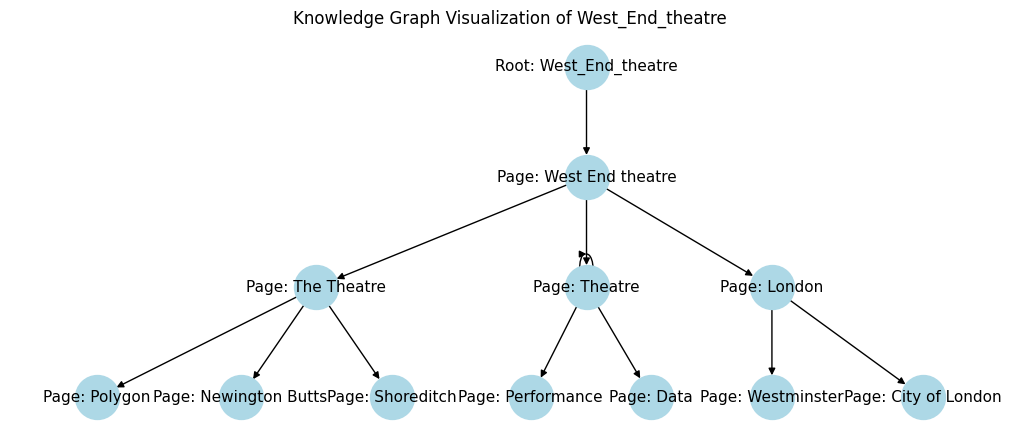

In [ ]:
from adapters.WikiKnowledgeGraph import KnowledgeGraph
kg = KnowledgeGraph("The_Terminator", None, skip_cr=True, cache_res=False)
kg.graph.visualize()

/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')
ERROR:root:wikipedia.exceptions.DisambiguationError for 'IGN'. picking random
ERROR:root:wikipedia.exceptions.DisambiguationError for 'Ent'. picking random
ERROR:root:wikipedia.exceptions.DisambiguationError for 'Film'. picking random
ERROR:root:wikipedia.exceptions.DisambiguationError for 'Devil'. pick

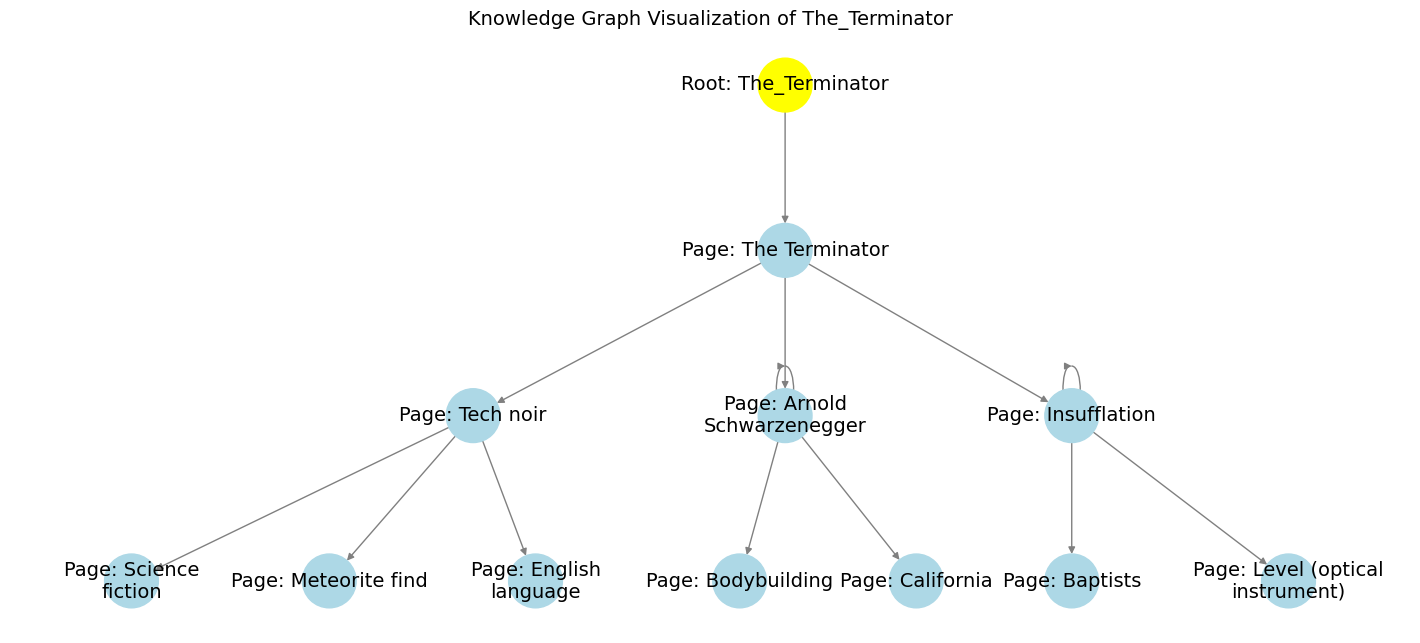

In [1]:
from adapters.WikiKnowledgeGraph import KnowledgeGraph
kg = KnowledgeGraph("The_Terminator", None, skip_cr=True, cache_res=False)
kg.graph.visualize()

In [ ]:
prefix_tracker = []
prefix_terminal_type = ["question_position_middle", "question_position_suffix"]
models = ["mistralai-Mistral-7B-Instruct-v0.2", "google-gemma-3-1b-it", "google-gemma-3-12b-it"]
path = "/vol/bitbucket/lst20/POPQA_treenodes/para/gemma3-12b_perturb/3_2_0/"
for model in models:
    for t in prefix_terminal_type:
        print(t)
        ids = check_ans(t, f"{path}{model}/complete/")
        print(model, len(ids))
        prefix_tracker.append((model, ids))

In [21]:
from similarity.cosine_similarity import similarity
from adapters.OAI_Embeddings import RobertaEmbedder
text_1 = "The quick brown fox jumps over the lazy dog."
 
text_2 = "The lazy dog was jumped over by the quick fox with brown fur"

embeder = RobertaEmbedder()
sim = similarity(embeder.encode(text_1) , embeder.encode(text_2))
sim

06/06/2025 00:01:12 - INFO - 	 Use pytorch device_name: cuda
06/06/2025 00:01:12 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-roberta-large-v1


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

/vol/bitbucket/lst20/lex-eval/lib/python3.12/site-packages/torch/__init__.py:1113: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

0.9111035466194153